In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. 데이터셋 생성

In [28]:
# 모듈 임포트
from modules.sdf_generator import create_sample_shape, to_grid
import numpy as np

# 1. 도형 생성 (Phase 1)
print("--- Phase 1: SDF 그리드 생성 ---")
my_shape = create_sample_shape()

--- Phase 1: SDF 그리드 생성 ---


### 1-2 sdf -> 파티클 샘플링 

### 2. sdf 계산(파티클 -> SDF)

In [ ]:

# my shape -> sdf 해상도 64로 설정
resolution = 64
sdf_grid = to_grid(my_shape, resolution=resolution, domain_size=2.0)

# 입자 샘플링을 위해 Numpy 포맷으로 저장
np.save("sdf_grid_64.npy", sdf_grid)

print(f"Grid Shape: {sdf_grid.shape}")
print(f"Min Value: {sdf_grid.min():.3f}, Max Value: {sdf_grid.max():.3f}")

### 2-1 sdf -> 파티클 샘플링 

### 2-2 CNN 학습

### 3. SDF 시각화

📂 'sdf_grid_64.npy' 로드 성공! Shape: (64, 64, 64)


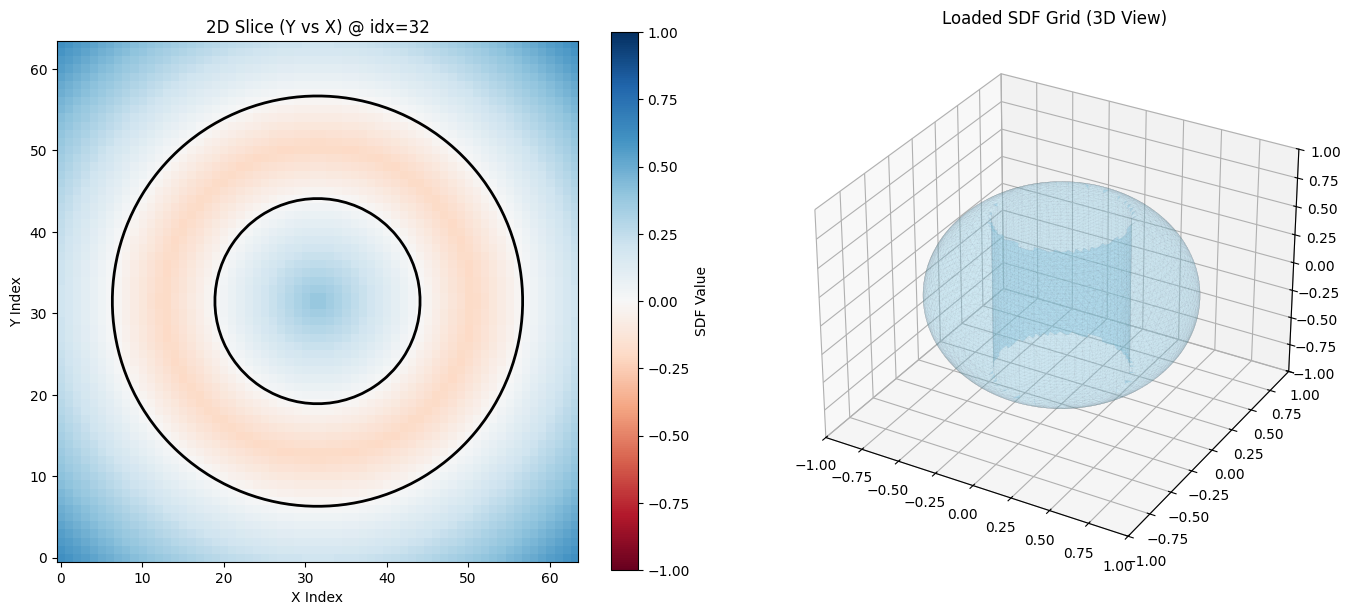

❌ 파일을 찾을 수 없습니다: particles.npy


In [ ]:
from modules.visualizer import visualize_npy
# 2. 데이터 시각화 (Phase 2)
print("\n--- Phase 2: 시각화 및 저장 ---")

# SDF 파일 확인
visualize_npy("sdf_grid_64.npy")

# 파티클 파일 확인
visualize_npy("particles.npy")


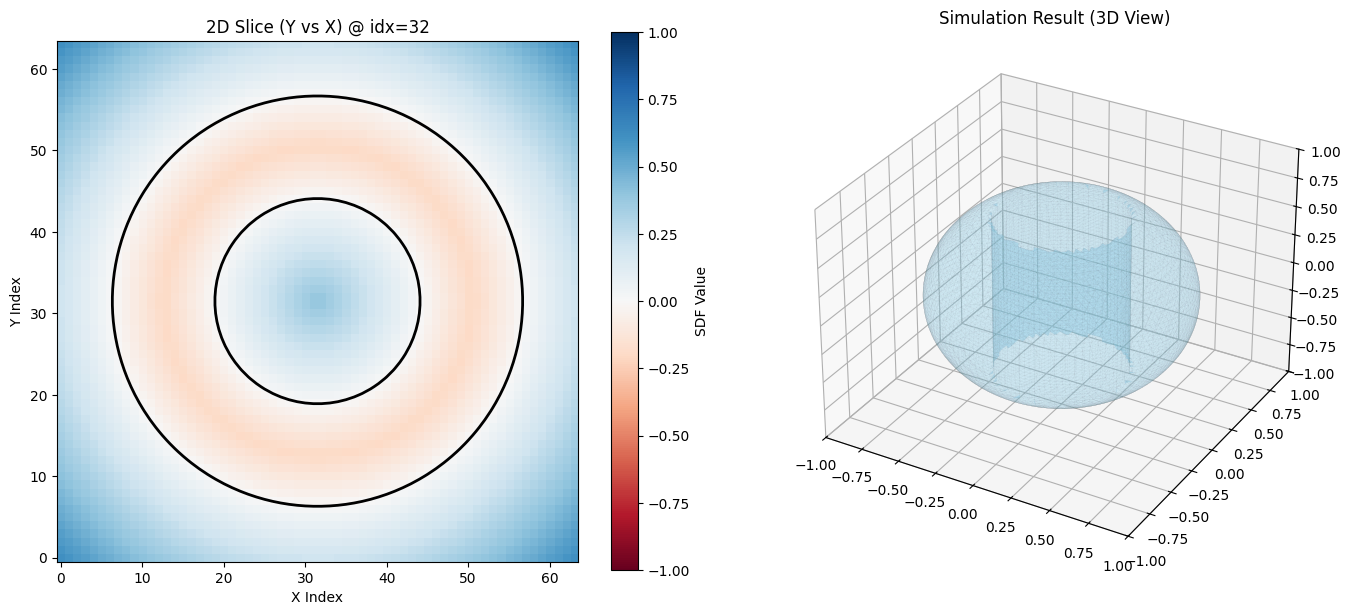

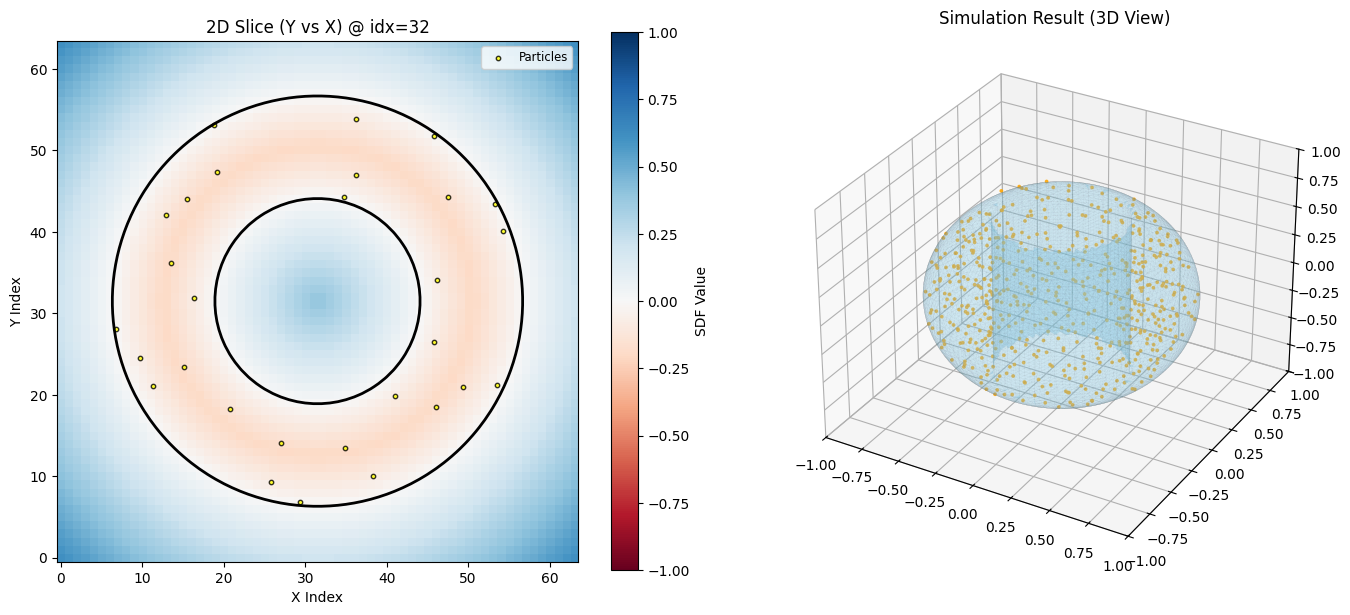

In [ ]:
from modules.visualizer import visualize_simulation

# SDF만 보기 (기존 plot_slice + 3D)
visualize_simulation(sdf_grid=sdf_grid)

# 파티클까지 겹쳐서 보기 (기존 plot_particles_and_sdf_slice + 3D)
visualize_simulation(sdf_grid=sdf_grid, particles=particles)

샘플링된 파티클 수: 598


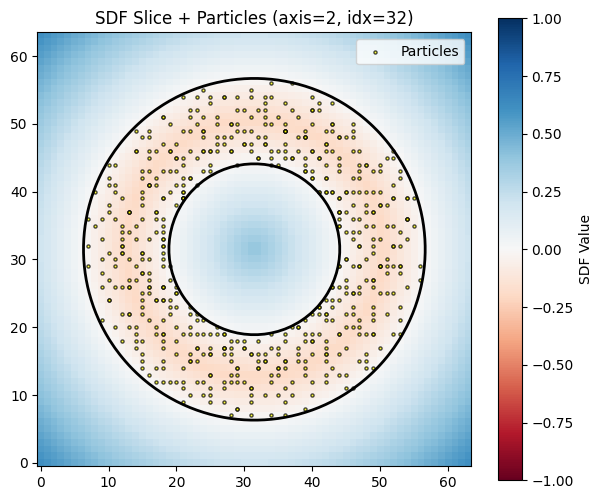

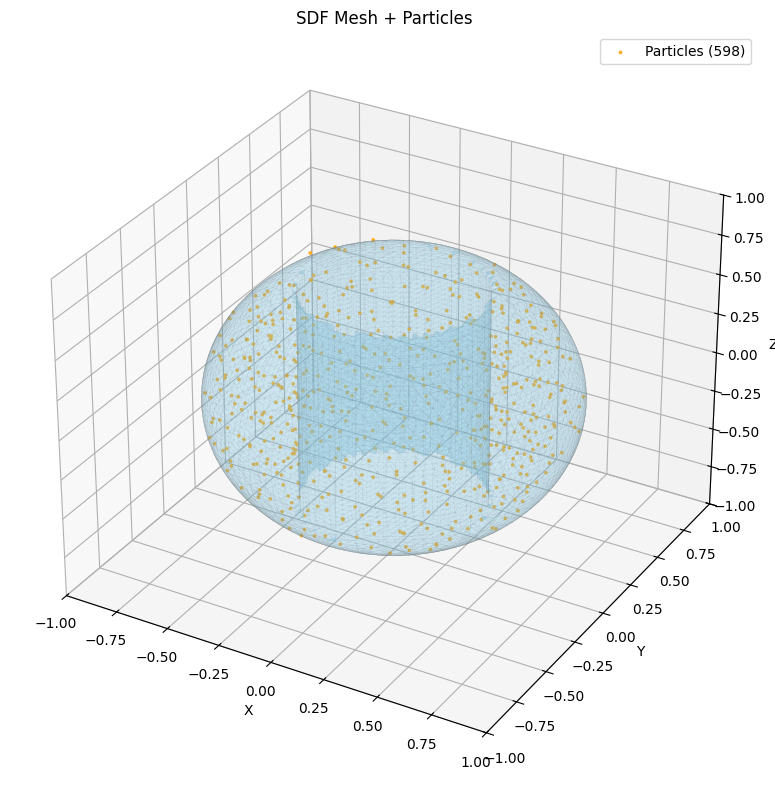

In [ ]:
from modules.particle_sampler import sample_particles_poisson, sample_particles_jittered, sample_particles_dart_throwing
from modules.visualizer import visualize_simulation

# SDF 그리드 불러오기
sdf_grid = np.load("sdf_grid_64.npy")

# dart throwing 방식 샘플링
particles = sample_particles_dart_throwing(sdf_grid, spacing = 0.1, max_trials=2000)
print(f"샘플링된 파티클 수: {len(particles)}")

visualize_simulation(sdf_grid=sdf_grid, particles=particles, domain_size=2.0)


샘플링된 파티클 수: 43616


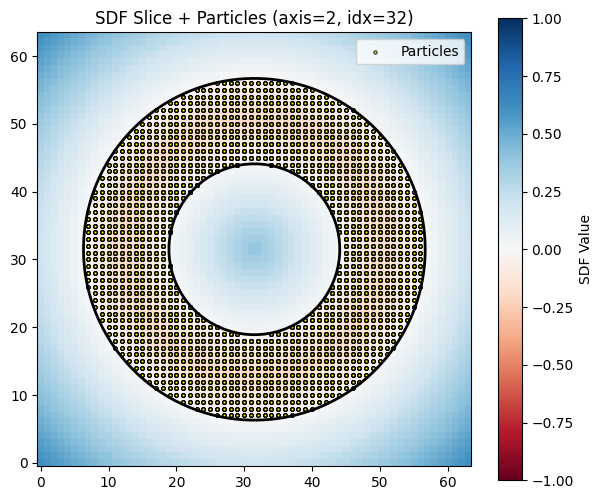

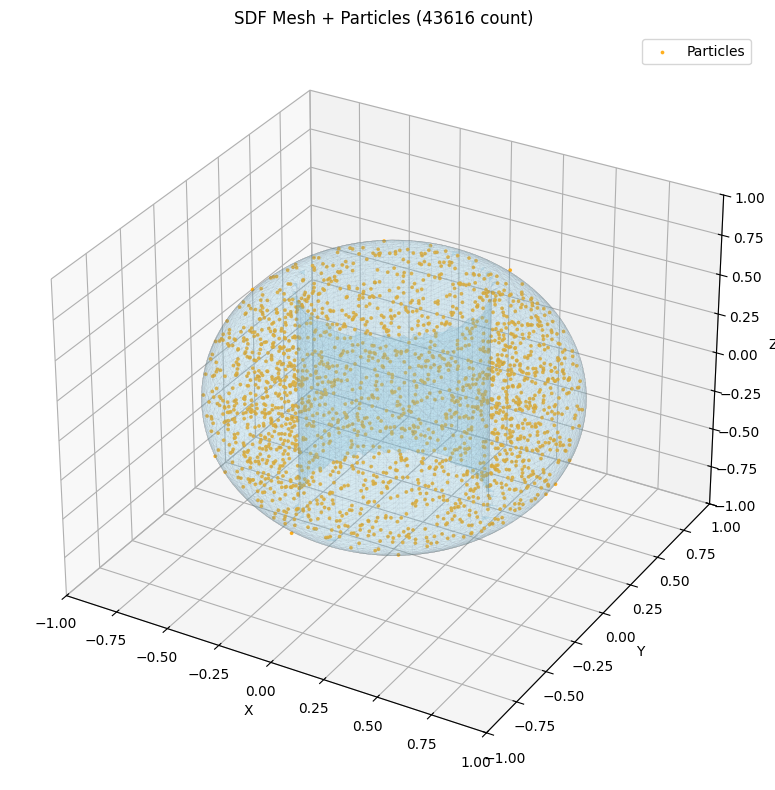

In [ ]:
from modules.particle_sampler import sample_particles_poisson, sample_particles_jittered, sample_particles_dart_throwing
from modules.visualizer import visualize_simulation

# SDF 그리드 불러오기
sdf_grid = np.load("sdf_grid_64.npy")

# jittered 방식 샘플링
particles = sample_particles_jittered(sdf_grid, domain_size=2.0, jitter_scale=0.8)
print(f"샘플링된 파티클 수: {len(particles)}")

visualize_simulation(sdf_grid=sdf_grid, particles=particles, domain_size=2.0)


   -> 목표 파티클: 2000개 / 추정 최소 거리(r): 0.0794
샘플링된 파티클 수: 195


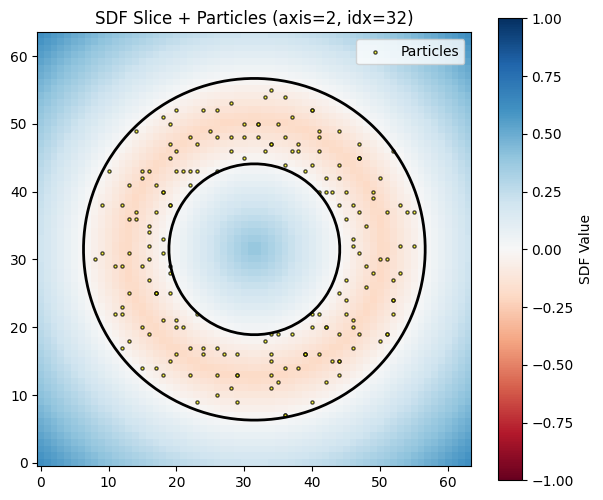

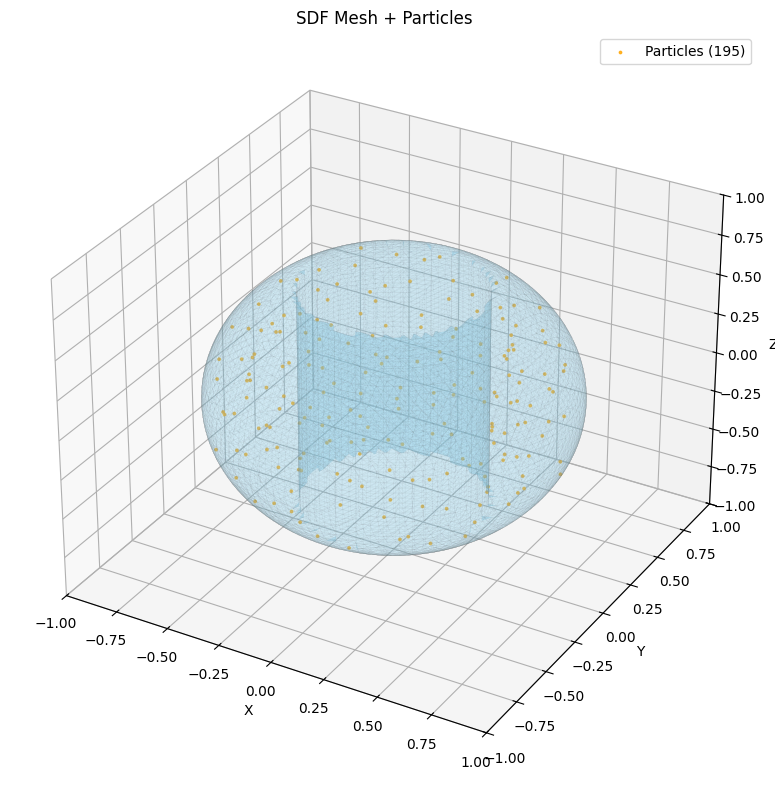

In [ ]:
from modules.particle_sampler import sample_particles_poisson, sample_particles_jittered, sample_particles_dart_throwing
from modules.visualizer import visualize_simulation

# SDF 그리드 불러오기
sdf_grid = np.load("sdf_grid_64.npy")

# Poisson Disk 방식 샘플링
particles = sample_particles_poisson(sdf_grid, domain_size=2.0, num_particles=2000)
print(f"샘플링된 파티클 수: {len(particles)}")

visualize_simulation(sdf_grid=sdf_grid, particles=particles, domain_size=2.0)
